# Réalisation du plan d'expérience de l'algorithme Hill Climbing Multi-Start (HC-MS)

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistiques sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- $i= 50$ : nombre de restarts par instance (paramètre unique de HC-MS)

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itérations
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimun et le maximum
- graphiques:
    - Trajectoire
    - influence de chaque paramètre (Heatmap à double entrée (type github)) -> tendance générale
    - Distance à la borne (`gap`)
- Meilleur paramètres

In [1]:
import sys

import numpy as np
import networkx as nx

sys.path.insert(0, "../")
sys.path.insert(0, "../algorithms/")

from graph_generator import generate_graph

### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `NB_ITERATIONS` : nombre de restarts de l'algorithme par instance

In [2]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_ITERATIONS: int = 50


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances

### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [3]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference

### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [4]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


In [5]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from helper import PENALTY_COST, calculate_tour_cost_with_penalty

# ─────────────────────────────────────────────────────────────────────────────
# Algorithme Hill Climbing Multi-Start (HC-MS)
# Reproduit depuis src/algorithms/hill_climbing_ms.py
#
# Note : le fichier source utilise `from ..helper import *` (import relatif)
# qui n'est pas compatible avec l'exécution directe d'un notebook.
# On importe donc `helper` directement via sys.path déjà configuré.
# Le comportement de l'algorithme est strictement identique.
# ─────────────────────────────────────────────────────────────────────────────

def _generate_random_tour(nodes: list) -> list:
    """Génère une solution initiale aléatoire (permutation des nœuds, dépôt fixe)."""
    tour: list = list(nodes)
    depot: int = tour[0]
    rest_of_tour: list = tour[1:]
    random.shuffle(rest_of_tour)
    return [depot] + rest_of_tour


def _get_neighbors(tour: list) -> list:
    """Génère le voisinage par échange 2-swap."""
    neighbors: list = []
    for i in range(1, len(tour) - 1):
        for j in range(i + 1, len(tour)):
            neighbor: list = tour.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors


def resolve_by_hill_climbing(graph: nx.Graph, initial_tour: list) -> tuple:
    """Exécute une passe de hill climbing depuis un tour initial."""
    current_tour: list = initial_tour
    current_cost: float = calculate_tour_cost_with_penalty(graph, current_tour)
    while True:
        neighbors: list = _get_neighbors(current_tour)
        best_neighbor = None
        best_neighbor_cost: float = current_cost
        for neighbor in neighbors:
            cost: float = calculate_tour_cost_with_penalty(graph, neighbor)
            if cost < best_neighbor_cost:
                best_neighbor = neighbor
                best_neighbor_cost = cost
        if best_neighbor is not None:
            current_tour = best_neighbor
            current_cost = best_neighbor_cost
        else:
            break
    return current_tour, current_cost


def resolve_by_ms_hill_climbing(graph: nx.Graph, iterations: int = 50) -> tuple:
    """Lance le HC depuis plusieurs points de départ aléatoires (multi-start)."""
    nodes: list = list(graph.nodes())
    global_best_tour = None
    global_best_cost: float = float("inf")
    for _ in range(iterations):
        initial_tour: list = _generate_random_tour(nodes)
        final_tour, final_cost = resolve_by_hill_climbing(graph, initial_tour)
        if final_cost < global_best_cost:
            global_best_cost = final_cost
            global_best_tour = final_tour
    if global_best_tour is None or global_best_cost >= PENALTY_COST:
        return [], float("inf")
    return global_best_tour, global_best_cost


def resolve_by_ms_hill_climbing_tracked(graph: nx.Graph, iterations: int = 50) -> tuple:
    """Variante instrumentée : retourne aussi l'historique du meilleur coût par restart."""
    nodes: list = list(graph.nodes())
    global_best_tour = None
    global_best_cost: float = float("inf")
    history: list = []
    for _ in range(iterations):
        initial_tour: list = _generate_random_tour(nodes)
        final_tour, final_cost = resolve_by_hill_climbing(graph, initial_tour)
        if final_cost < global_best_cost:
            global_best_cost = final_cost
            global_best_tour = final_tour
        history.append(global_best_cost if global_best_cost < float("inf") else None)
    if global_best_tour is None or global_best_cost >= PENALTY_COST:
        return [], float("inf"), history
    return global_best_tour, global_best_cost, history


print("✓ Algorithme Hill Climbing Multi-Start chargé.")

✓ Algorithme Hill Climbing Multi-Start chargé.


## Étude de trajectoire

On observe l'évolution du **meilleur coût global** au fil des redémarrages (*restarts*) pour une instance représentative par taille de graphe.

La trajectoire prend la forme d'un **escalier descendant** : le meilleur coût ne peut que décroître ou rester stable d'un restart à l'autre, car on garde toujours la meilleure solution trouvée.

La **ligne rouge** en pointillés représente la borne inférieure (référence `lower_bound_min_outgoing`) vers laquelle on cherche à converger.

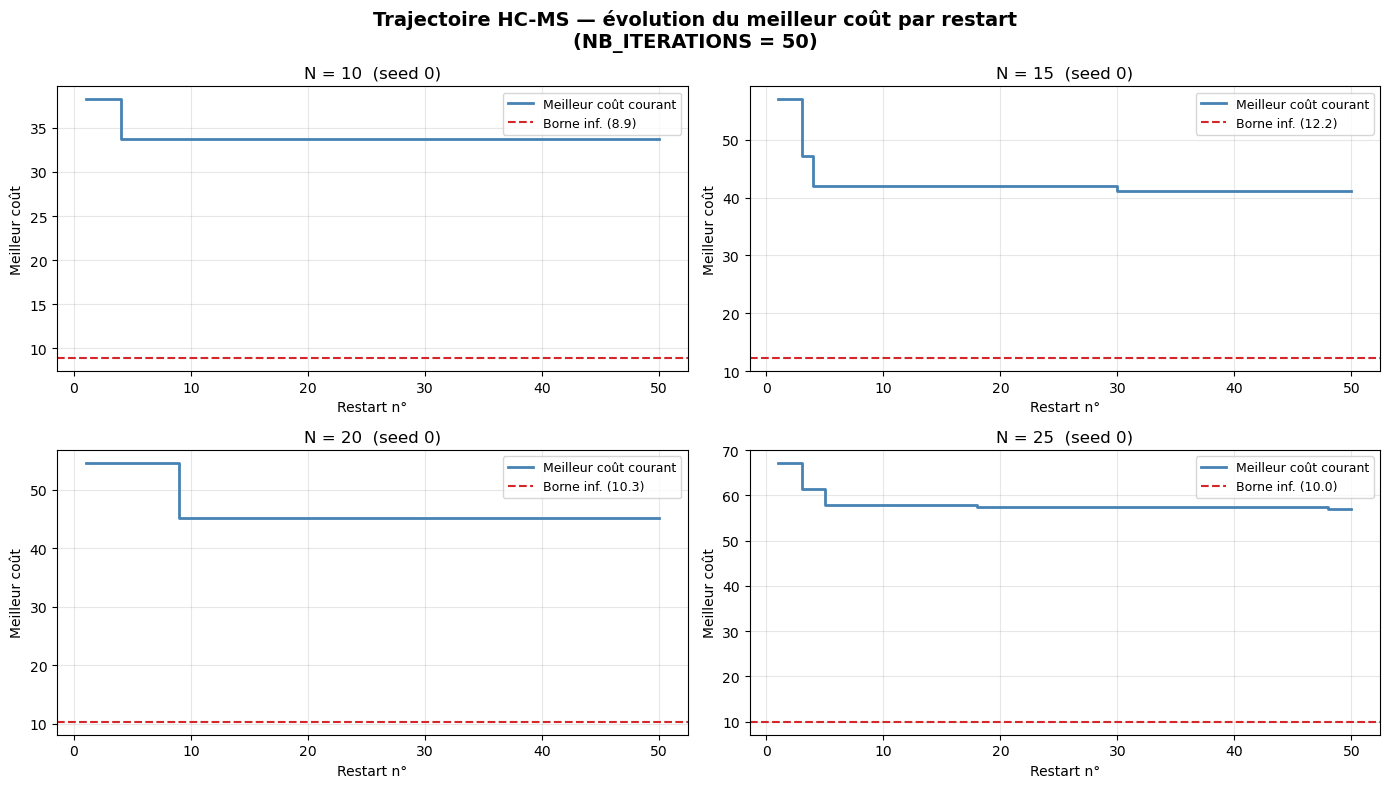

In [6]:
# ── Étude de trajectoire ──────────────────────────────────────────────────────
# On visualise l'évolution du meilleur coût sur 4 tailles représentatives.
# Seed fixé à 0 pour la reproductibilité.

TRAJ_N_DISPLAY: list[int] = [10, 15, 20, 25]   # sous-ensemble de N_VALUES
TRAJ_SEED: int = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, n in zip(axes, TRAJ_N_DISPLAY):
    seed, graph, ref = next(
        (s, g, r) for s, g, r in instances[n] if s == TRAJ_SEED
    )
    _, _, history = resolve_by_ms_hill_climbing_tracked(graph, iterations=NB_ITERATIONS)

    # Remplacer None (aucun tour valide trouvé avant ce restart) par la dernière valeur connue
    clean_history: list[float] = []
    last_valid: float = float("nan")
    for v in history:
        if v is not None:
            last_valid = v
        clean_history.append(last_valid)

    restarts: list[int] = list(range(1, len(clean_history) + 1))

    ax.step(restarts, clean_history, where="post",
            linewidth=2, color="steelblue", label="Meilleur coût courant")
    ax.axhline(y=ref, color="#d62728", linestyle="--", linewidth=1.5,
               label=f"Borne inf. ({ref:.1f})")
    ax.set_title(f"N = {n}  (seed {TRAJ_SEED})", fontsize=12)
    ax.set_xlabel("Restart n°", fontsize=10)
    ax.set_ylabel("Meilleur coût", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Trajectoire HC-MS — évolution du meilleur coût par restart\n"
    f"(NB_ITERATIONS = {NB_ITERATIONS})",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Étude de l'influence des paramètres

Le seul paramètre de l'algorithme HC-MS est **`iterations`** (nombre de redémarrages).

Pour mesurer son influence, on fait varier `iterations` sur une plage de valeurs et on mesure le **gap moyen** obtenu sur l'ensemble des `NB_SEEDS` instances de chaque taille $N$.

La **heatmap à double entrée** (style GitHub) ci-dessous présente :
- En **lignes** : les tailles de graphe $N \in \{10, 12, 15, 17, 20, 22, 25, 30\}$
- En **colonnes** : les valeurs d'`iterations` testées
- La **couleur** code le gap moyen (%) — *plus clair = meilleur résultat (gap plus faible)*

In [14]:
# ── Calcul principal ──────────────────────────────────────────────────────────
# On fait varier `iterations` et on enregistre les résultats pour chaque (N, iterations).
#
# Ce calcul peut prendre quelques minutes selon la machine.
# Estimation : ~3-8 minutes pour l'ensemble des 640 exécutions.
#
# Données stockées :
#   gap_matrix[n][it]   = gap moyen (%) — pour la heatmap
#   cost_results[n][it] = liste des coûts valides — pour les statistiques
#   gap_results[n][it]  = liste des gaps (%) — pour les courbes

ITERATIONS_RANGE: list[int] = [1, 5, 10, 20, 30, 50]

gap_matrix: dict   = {}
cost_results: dict = {}
gap_results: dict  = {}

nb_total: int = len(N_VALUES) * len(ITERATIONS_RANGE) * NB_SEEDS
print(f"Calcul en cours : {len(N_VALUES)} tailles × {len(ITERATIONS_RANGE)} valeurs "
      f"× {NB_SEEDS} seeds = {nb_total} exécutions\n")

for n in N_VALUES:
    gap_matrix[n]   = {}
    cost_results[n] = {}
    gap_results[n]  = {}
    for it in ITERATIONS_RANGE:
        costs: list[float] = []
        gaps:  list[float] = []
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_ms_hill_climbing(graph, iterations=it)
            if cost < PENALTY_COST:
                costs.append(cost)
                gaps.append(compute_gap(cost, ref))
        cost_results[n][it] = costs
        gap_results[n][it]  = gaps
        gap_matrix[n][it]   = float(np.nanmean(gaps)) if gaps else float("nan")
    row_summary = {it: f"{gap_matrix[n][it]:.1f}" for it in ITERATIONS_RANGE}
    print(f"  N={n:2d} : {row_summary}")

print("\n✓ Calcul terminé.")

Calcul en cours : 8 tailles × 6 valeurs × 10 seeds = 480 exécutions

  N=10 : {1: '331.9', 5: '271.8', 10: '272.7', 20: '257.6', 30: '259.2', 50: '255.7'}
  N=12 : {1: '401.8', 5: '342.7', 10: '331.3', 20: '300.0', 30: '295.8', 50: '289.0'}
  N=15 : {1: '486.2', 5: '400.8', 10: '367.1', 20: '357.2', 30: '328.7', 50: '328.2'}
  N=17 : {1: '594.2', 5: '415.9', 10: '418.5', 20: '410.9', 30: '392.2', 50: '370.7'}
  N=20 : {1: '581.0', 5: '522.0', 10: '473.0', 20: '443.1', 30: '415.8', 50: '393.8'}
  N=22 : {1: '616.1', 5: '570.4', 10: '507.0', 20: '456.9', 30: '469.5', 50: '415.1'}
  N=25 : {1: '632.5', 5: '571.1', 10: '521.5', 20: '480.9', 30: '513.1', 50: '471.9'}
  N=30 : {1: '703.3', 5: '614.5', 10: '586.1', 20: '554.8', 30: '538.0', 50: '505.4'}

✓ Calcul terminé.


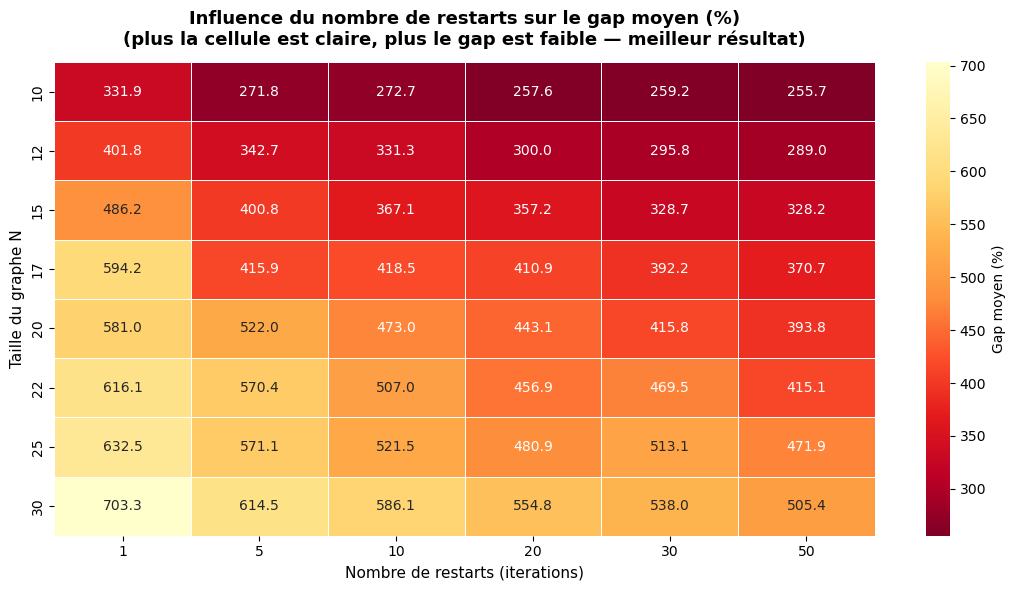

In [15]:
# ── Heatmap N × iterations → gap moyen ───────────────────────────────────────

heatmap_df = pd.DataFrame(gap_matrix, index=ITERATIONS_RANGE).T
heatmap_df.index.name   = "N"
heatmap_df.columns.name = "Iterations"

fig, ax = plt.subplots(figsize=(11, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd_r",           # plus clair = meilleur (gap plus faible)
    linewidths=0.6,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Gap moyen (%)"},
)

ax.set_title(
    "Influence du nombre de restarts sur le gap moyen (%)\n"
    "(plus la cellule est claire, plus le gap est faible — meilleur résultat)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Nombre de restarts (iterations)", fontsize=11)
ax.set_ylabel("Taille du graphe N", fontsize=11)
plt.tight_layout()
plt.show()

## Statistiques qualité des solutions

Pour `iterations = NB_ITERATIONS = 50`, on calcule les **statistiques descriptives** sur l'ensemble des `NB_SEEDS` exécutions par taille de graphe $N$ :

| Indicateur | Description |
|---|---|
| Meilleur / Pire coût | Coût min/max obtenu sur toutes les seeds |
| Coût moyen / médian | Tendance centrale des coûts |
| Écart-type coût | Variabilité des coûts selon le point de départ |
| Gap min / moyen / max / médian (%) | Distance relative à la borne inférieure |
| Écart-type gap (%) | Variabilité du gap |
| Taux de succès | Proportion d'instances où une tournée valide a été trouvée |

> **Note :** les données proviennent du calcul effectué dans la cellule *Calcul principal* ci-dessus.

In [16]:
# ── Statistiques pour iterations = NB_ITERATIONS ─────────────────────────────
# Réutilise cost_results et gap_results calculés dans la cellule précédente.

stats_rows: list[dict] = []

for n in N_VALUES:
    costs: list[float] = cost_results[n][NB_ITERATIONS]
    gaps:  list[float] = gap_results[n][NB_ITERATIONS]

    if costs:
        stats_rows.append({
            "N":                    n,
            "Meilleur coût":        round(min(costs), 2),
            "Pire coût":            round(max(costs), 2),
            "Coût moyen":           round(float(np.mean(costs)), 2),
            "Coût médian":          round(float(np.median(costs)), 2),
            "Écart-type coût":      round(float(np.std(costs)), 2),
            "Gap min (%)":          round(min(gaps), 2),
            "Gap max (%)":          round(max(gaps), 2),
            "Gap moyen (%)":        round(float(np.mean(gaps)), 2),
            "Gap médian (%)":       round(float(np.median(gaps)), 2),
            "Écart-type gap (%)":   round(float(np.std(gaps)), 2),
            "Taux de succès":       f"{len(costs)}/{NB_SEEDS}",
        })
    else:
        stats_rows.append({"N": n, "Taux de succès": f"0/{NB_SEEDS}"})

df_stats = pd.DataFrame(stats_rows).set_index("N")

print(f"Statistiques des solutions — iterations = {NB_ITERATIONS}\n")
display(df_stats)

Statistiques des solutions — iterations = 50



,Meilleur coût,Pire coût,Coût moyen,Coût médian,Écart-type coût,Gap min (%),Gap max (%),Gap moyen (%),Gap médian (%),Écart-type gap (%),Taux de succès
N,,,,,,,,,,,
10,33.75,50.10,40.02,38.77,5.23,217.50,287.30,255.71,257.29,26.92,8/10
12,35.40,67.10,44.71,39.90,10.57,160.18,414.29,289.02,280.15,77.05,8/10
15,38.10,58.65,45.77,44.32,7.38,219.02,407.79,328.25,348.93,70.92,8/10
17,35.85,59.10,46.03,45.15,7.38,251.79,476.60,370.69,382.50,64.37,8/10
20,38.55,68.00,49.54,47.85,9.46,272.46,592.86,393.76,387.46,91.60,8/10
22,37.20,66.15,50.74,49.27,10.06,294.03,588.89,415.13,366.77,109.88,8/10
25,46.95,71.40,57.27,57.67,6.73,352.22,636.47,471.90,463.23,84.28,8/10
30,58.35,76.35,63.30,60.30,5.79,400.63,570.69,505.39,534.15,64.08,8/10


## Distance à la borne (gap)

Le **gap** mesure l'écart relatif entre la solution trouvée et la borne inférieure :

$$\text{gap} = 100 \times \frac{\text{coût} - \text{borne}}{\text{borne}} \quad (\%)$$

- Un **gap proche de 0 %** indique que l'algorithme s'approche de l'optimal théorique.
- On observe comment le gap **évolue avec la taille $N$** du problème.
- La **zone ombrée** représente l'écart-type entre les `NB_SEEDS` seeds (variabilité).

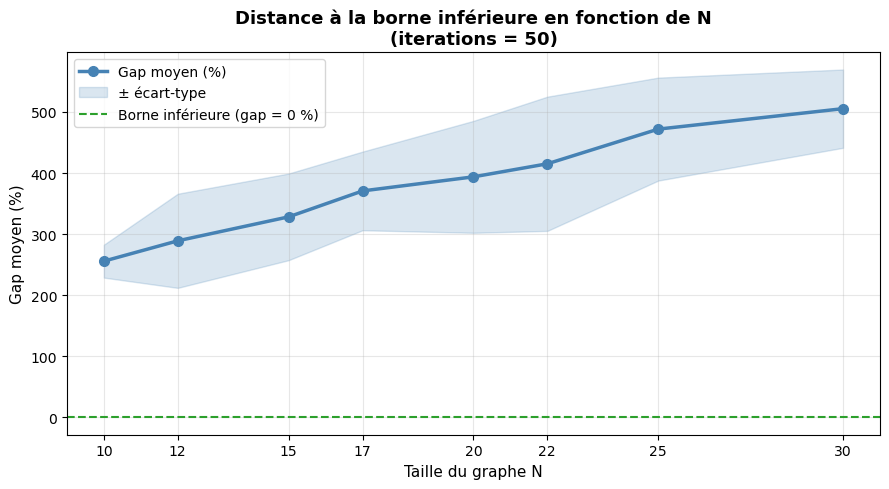

In [17]:
# ── Courbe gap moyen ± écart-type en fonction de N ────────────────────────────
# Réutilise gap_results calculés dans la cellule Calcul principal.

gap_means_arr = np.array([
    float(np.mean(gap_results[n][NB_ITERATIONS])) if gap_results[n][NB_ITERATIONS] else float("nan")
    for n in N_VALUES
])
gap_stds_arr = np.array([
    float(np.std(gap_results[n][NB_ITERATIONS])) if gap_results[n][NB_ITERATIONS] else float("nan")
    for n in N_VALUES
])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(N_VALUES, gap_means_arr, "o-", linewidth=2.5, markersize=7,
        color="steelblue", label="Gap moyen (%)")
ax.fill_between(
    N_VALUES,
    np.clip(gap_means_arr - gap_stds_arr, 0, None),
    gap_means_arr + gap_stds_arr,
    alpha=0.20, color="steelblue", label="± écart-type",
)
ax.axhline(y=0, color="#2ca02c", linestyle="--", linewidth=1.5,
           label="Borne inférieure (gap = 0 %)")

ax.set_title(
    f"Distance à la borne inférieure en fonction de N\n"
    f"(iterations = {NB_ITERATIONS})",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Définition des paramètres optimisés

On identifie la valeur de `iterations` qui **minimise le gap moyen global** (moyenné sur toutes les tailles de graphe $N$ et toutes les seeds).

Le barplot ci-dessous synthétise les résultats de l'étude paramétrique :
- La barre **rouge** correspond à la valeur optimale.
- Les valeurs plus élevées d'`iterations` améliorent la qualité mais augmentent le temps de calcul.

  RÉSULTATS — Hill Climbing Multi-Start

  Gap moyen global par nombre de restarts :

    iterations =    1  →  gap moyen = 543.36 %
    iterations =    5  →  gap moyen = 463.65 %
    iterations =   10  →  gap moyen = 434.64 %
    iterations =   20  →  gap moyen = 407.66 %
    iterations =   30  →  gap moyen = 401.54 %
    iterations =   50  →  gap moyen = 378.73 %  ◄ OPTIMAL

  ────────────────────────────────────────────────
  Meilleur paramètre : iterations = 50
  Gap moyen obtenu   : 378.73 %
  (NB_ITERATIONS = 50 confirme la valeur optimale)


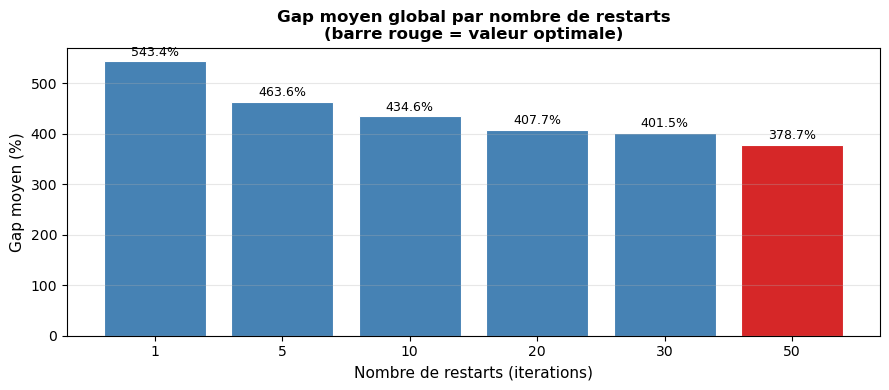

In [18]:
# ── Meilleurs paramètres ─────────────────────────────────────────────────────
# Critère : minimiser le gap moyen global (moyenne sur tous les N et toutes les seeds)

global_gap_by_it: dict[int, float] = {}
for it in ITERATIONS_RANGE:
    all_gaps: list[float] = []
    for n in N_VALUES:
        all_gaps.extend(gap_results[n][it])
    global_gap_by_it[it] = float(np.nanmean(all_gaps)) if all_gaps else float("nan")

best_it: int    = min(global_gap_by_it, key=lambda k: global_gap_by_it[k])
best_gap: float = global_gap_by_it[best_it]

print("=" * 62)
print("  RÉSULTATS — Hill Climbing Multi-Start")
print("=" * 62)
print(f"\n  Gap moyen global par nombre de restarts :\n")
for it in sorted(global_gap_by_it):
    arrow = "  ◄ OPTIMAL" if it == best_it else ""
    print(f"    iterations = {it:4d}  →  gap moyen = {global_gap_by_it[it]:6.2f} %{arrow}")

print(f"\n  {'─' * 48}")
print(f"  Meilleur paramètre : iterations = {best_it}")
print(f"  Gap moyen obtenu   : {best_gap:.2f} %")
if best_it != NB_ITERATIONS:
    print(f"  (NB_ITERATIONS courant = {NB_ITERATIONS}, "
          f"différent de l'optimum trouvé = {best_it})")
else:
    print(f"  (NB_ITERATIONS = {NB_ITERATIONS} confirme la valeur optimale)")
print("=" * 62)

# ── Barplot récapitulatif ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

its_sorted  = sorted(global_gap_by_it.keys())
gaps_sorted = [global_gap_by_it[i] for i in its_sorted]
bar_colors  = ["#d62728" if i == best_it else "steelblue" for i in its_sorted]

bars = ax.bar([str(i) for i in its_sorted], gaps_sorted,
              color=bar_colors, edgecolor="white", linewidth=0.8)

for bar, gap_val in zip(bars, gaps_sorted):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(gaps_sorted) * 0.01,
        f"{gap_val:.1f}%",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title(
    "Gap moyen global par nombre de restarts\n"
    "(barre rouge = valeur optimale)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Nombre de restarts (iterations)", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()